In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import ast

In [6]:
df = pd.read_csv('./data/df_alter.csv')

In [ ]:
import pandas as pd
import ast
import networkx as nx


# Build mapping from UUID -> concept name
# Guessing the UUID column is 'networkCanvasUUID' and the name column is 'name'
uuid_col = 'networkCanvasUUID'
name_col = 'name'

mapping = dict(zip(df[uuid_col], df[name_col]))

# Helper to safely parse the connected_concepts column (some rows may be NaN)
def parse_connected(s):
    if pd.isna(s):
        return []
    if isinstance(s, list):
        return s
    try:
        return ast.literal_eval(s)
    except Exception:
        # fallback: try to strip brackets and split by comma
        s2 = str(s).strip("[]")
        if not s2:
            return []
        return [x.strip().strip("'\"") for x in s2.split(",") if x.strip()]

# Create graph
G = nx.Graph()

# Add nodes (use names as nodes)
for uuid, name in mapping.items():
    G.add_node(name, uuid=uuid)

# Build weighted edges
missing_uuids = set()
for idx, row in df.iterrows():
    this_uuid = row.get(uuid_col)
    this_name = mapping.get(this_uuid, None)
    connected_raw = row.get('connected_concepts', None)
    connected_list = parse_connected(connected_raw)
    for other_uuid in connected_list:
        other_name = mapping.get(other_uuid)
        if other_name is None:
            # record missing and use uuid as fallback node name to avoid losing connectivity
            missing_uuids.add(other_uuid)
            other_name = other_uuid  # fallback
            if other_name not in G:
                G.add_node(other_name, uuid=other_uuid)
        # Avoid self-loops where name equals other_name
        if this_name is None:
            # If the source name is missing, use the uuid as fallback
            this_name = this_uuid if pd.notna(this_uuid) else f"unknown_{idx}"
            if this_name not in G:
                G.add_node(this_name, uuid=this_uuid)
        if this_name == other_name:
            continue
        if G.has_edge(this_name, other_name):
            G[this_name][other_name]['weight'] += 1
        else:
            G.add_edge(this_name, other_name, weight=1)

# Export graph files
gexf_path = "./data/concept_network.gexf"
graphml_path = "./data/concept_network.graphml"
edgelist_csv_path = "./data/concept_network_edgelist.csv"

nx.write_gexf(G, gexf_path)
try:
    nx.write_graphml(G, graphml_path)
except Exception as e:
    # networkx GraphML may fail for non-string attributes; we'll remove non-string attributes safely
    G_for_graphml = nx.Graph()
    for u, v, data in G.edges(data=True):
        G_for_graphml.add_edge(str(u), str(v), weight=int(data.get('weight', 1)))
    nx.write_graphml(G_for_graphml, graphml_path)

# Write edgelist CSV: source, target, weight
edges = [(u, v, data.get('weight', 1)) for u, v, data in G.edges(data=True)]
edges_df = pd.DataFrame(edges, columns=['source', 'target', 'weight'])
edges_df.to_csv(edgelist_csv_path, index=False)

# Summary table of top edges by weight for quick inspection
top_edges = edges_df.sort_values('weight', ascending=False).head(20)

# Output summary info
node_count = G.number_of_nodes()
edge_count = G.number_of_edges()
num_missing_uuid = len(missing_uuids)

print(f"Exported files:\n - GEXF: {gexf_path}\n - GraphML: {graphml_path}\n - Edgelist CSV: {edgelist_csv_path}")
print(f"Graph summary: {node_count} nodes, {edge_count} edges.")

Exported files:
 - GEXF: ./data/concept_network.gexf
 - GraphML: ./data/concept_network.graphml
 - Edgelist CSV: ./data/concept_network_edgelist.csv
Graph summary: 38 nodes, 153 edges.
Note: 0 connected UUIDs were present in 'connected_concepts' but had no matching row in the CSV; they were kept using their UUID as node names as a fallback.


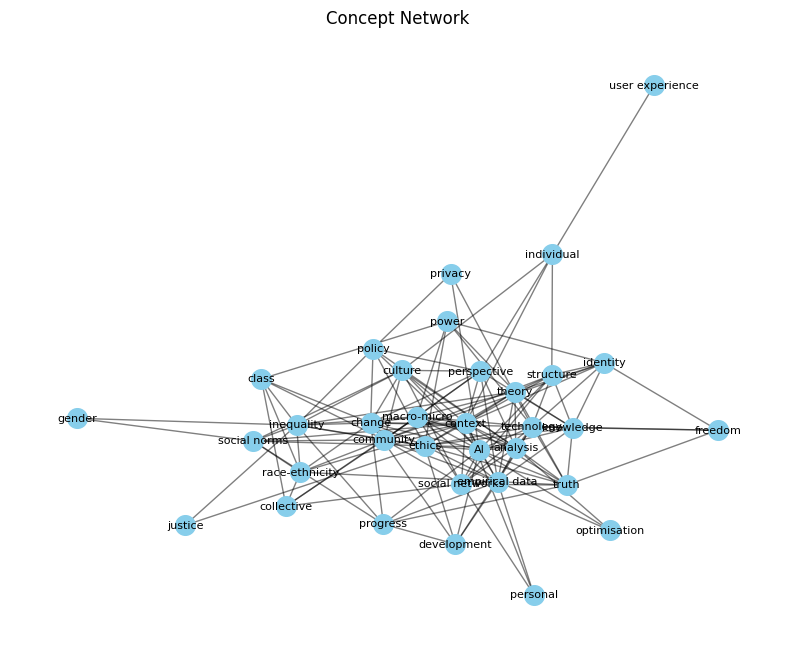

In [ ]:
edges = pd.read_csv("./data/concept_network_edgelist.csv")
G = nx.Graph()
for _, row in edges.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

# Draw the network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)  # Layout algorithm
nx.draw_networkx_nodes(G, pos, node_size=200, node_color="skyblue")
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("Concept Network")
plt.axis("off")
plt.show()